# ZooLake - final ConvNeXtBase run with corrected semantic split

This is the final pre-registered image-model experiment:

- corrected deduplicated authors' split: 12,558 train / 2,691 validation / 2,691 final test;
- authors' public-code augmentation: rotation range 90 degrees, horizontal and
  vertical flips, zoom 20%, and shear 10;
- ImageNet ConvNeXtBase with the same BN-free head as the previous best run;
- frozen-head training followed by full fine-tuning;
- natural sampling, categorical cross-entropy, and no class weights;
- model selection only from validation loss;
- final-test pixels are not loaded until the fine-tuned checkpoint has been fixed.

The paper text reports rotations up to 180 degrees, while the released
src/helper_models.py uses rotation_range=90. This notebook deliberately follows
the executable public-code augmentation. ConvNeXtBase and ReduceLROnPlateau are
our optimized extension, not architectures/settings claimed by the 2021 paper.

Kaggle inputs:

1. zoolake_paper_split_deduplicated_semantic.csv
2. the complete zooplankton_0p5x image directory

Enable a GPU and Internet before Run All. Internet is required for the initial
ImageNet weight download.


In [1]:
import hashlib
import io
import json
import platform
import random
import sys
import time
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator


SEED = 12345
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 32
NUM_CLASSES = 35

RUN_NAME = "convnextbase_zoolake_final_public_aug_correct_split_seed12345"
MANIFEST_FILENAME = "zoolake_paper_split_deduplicated_semantic.csv"
EXPECTED_MANIFEST_SHA256 = (
    "84ca050319a314f1fbf532f553c1a557763b73a09b2e0f0692d2d6c8182706ad"
)
HOLDOUT_OVERLAP_FILENAME = (
    "SPC-EAWAG-0P5X-1589537326874154-10282734293288-"
    "005169-028-1252-974-40-64.jpeg"
)

FROZEN_LEARNING_RATE = 1e-4
FROZEN_MAX_EPOCHS = 200
FROZEN_EARLY_STOPPING_PATIENCE = 50

FINETUNE_LEARNING_RATE = 1e-6
FINETUNE_MAX_EPOCHS = 400
FINETUNE_EARLY_STOPPING_PATIENCE = 80
REDUCE_LR_FACTOR = 0.2
REDUCE_LR_PATIENCE = 20
REDUCE_LR_MIN_DELTA = 1e-4
MIN_LEARNING_RATE = 1e-8

TOTAL_PIPELINE_WALL_TIME_LIMIT_HOURS = 11.25
BOOTSTRAP_RESAMPLES = 2000

# Normally leave these as None. Exact-name discovery then searches /kaggle/input.
EXPLICIT_MANIFEST_PATH = None
EXPLICIT_DATASET_ROOT = None

OUTPUT_DIR = Path("/kaggle/working") / RUN_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BEST_FROZEN_MODEL_PATH = OUTPUT_DIR / "best_frozen_model.keras"
BEST_FINETUNED_MODEL_PATH = OUTPUT_DIR / "best_finetuned_model.keras"

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("Python:", sys.version.split()[0])
print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))
print("Mixed precision policy:", tf.keras.mixed_precision.global_policy())

assert tf.config.list_physical_devices("GPU"), (
    "Enable a Kaggle GPU accelerator before training."
)
assert hasattr(tf.keras.applications, "ConvNeXtBase"), (
    "This TensorFlow/Keras version has no ConvNeXtBase."
)


Python: 3.12.13
TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision policy: <DTypePolicy "float32">


## 1. Utilities and reporting

The global wall-time callback protects the 12-hour Kaggle session. The saved
best checkpoint, rather than the last in-memory epoch, is always used for the
next stage and for final evaluation.


In [2]:
def write_json(path, data):
    with open(path, "w", encoding="utf-8") as file:
        json.dump(data, file, indent=2, ensure_ascii=False)


def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as file:
        while chunk := file.read(chunk_size):
            digest.update(chunk)
    return digest.hexdigest()


def resolve_exact_file(explicit_path, exact_name, description):
    if explicit_path is not None:
        path = Path(explicit_path)
        assert path.is_file(), f"{description} not found: {path}"
        assert path.name == exact_name, (
            f"{description} must be named {exact_name}, got {path.name}"
        )
        return path

    candidates = sorted(
        path
        for path in Path("/kaggle/input").rglob(exact_name)
        if path.is_file()
    )
    if len(candidates) != 1:
        raise FileNotFoundError(
            f"Expected exactly one {description} named {exact_name}; "
            f"found {len(candidates)}: {candidates}"
        )
    return candidates[0]


def resolve_exact_directory(explicit_path, exact_name, description):
    if explicit_path is not None:
        path = Path(explicit_path)
        assert path.is_dir(), f"{description} not found: {path}"
        assert path.name == exact_name, (
            f"{description} must be named {exact_name}, got {path.name}"
        )
        return path

    candidates = sorted(
        path
        for path in Path("/kaggle/input").rglob(exact_name)
        if path.is_dir()
    )
    if len(candidates) != 1:
        raise FileNotFoundError(
            f"Expected exactly one {description} named {exact_name}; "
            f"found {len(candidates)}: {candidates}"
        )
    return candidates[0]


def recursive_layers(layer):
    result = []
    for child in getattr(layer, "layers", []):
        result.append(child)
        result.extend(recursive_layers(child))
    return result


def set_trainable_recursive(layer, value):
    layer.trainable = value
    for child in getattr(layer, "layers", []):
        set_trainable_recursive(child, value)


def parameter_count(weights):
    return int(sum(np.prod(variable.shape) for variable in weights))


class StageEpochLogger(tf.keras.callbacks.Callback):
    def __init__(
        self,
        stage,
        output_path,
        pipeline_started_at,
        wall_time_limit_hours,
    ):
        super().__init__()
        self.stage = stage
        self.output_path = Path(output_path)
        self.pipeline_started_at = pipeline_started_at
        self.wall_time_limit_seconds = wall_time_limit_hours * 3600
        self.stage_started_at = None
        self.epoch_started_at = None
        self.rows = []
        self.stopped_by_time_limit = False
        if self.output_path.exists():
            self.output_path.unlink()

    def on_train_begin(self, logs=None):
        self.stage_started_at = time.perf_counter()

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_started_at = time.perf_counter()

    def on_epoch_end(self, epoch, logs=None):
        logs = logs if logs is not None else {}
        learning_rate = float(
            tf.keras.backend.get_value(self.model.optimizer.learning_rate)
        )
        pipeline_seconds = time.perf_counter() - self.pipeline_started_at
        stage_seconds = time.perf_counter() - self.stage_started_at
        epoch_seconds = time.perf_counter() - self.epoch_started_at

        logs["learning_rate"] = learning_rate
        self.rows.append({
            "stage": self.stage,
            "epoch": int(epoch + 1),
            "epoch_seconds": float(epoch_seconds),
            "stage_seconds": float(stage_seconds),
            "pipeline_seconds": float(pipeline_seconds),
            "learning_rate": learning_rate,
        })
        pd.DataFrame(self.rows).to_csv(self.output_path, index=False)

        if pipeline_seconds >= self.wall_time_limit_seconds:
            self.stopped_by_time_limit = True
            self.model.stop_training = True
            print(
                "Stopping at the global wall-time guard after "
                f"{pipeline_seconds / 3600:.2f} hours."
            )


def history_with_timing(history, timing_path, output_path):
    history_df = pd.DataFrame(history.history)
    history_df.insert(0, "epoch", np.arange(1, len(history_df) + 1))
    timing_df = pd.read_csv(timing_path)
    assert len(history_df) == len(timing_df)
    for column in [
        "epoch_seconds",
        "stage_seconds",
        "pipeline_seconds",
        "learning_rate",
    ]:
        history_df[column] = timing_df[column].to_numpy()
    history_df.to_csv(output_path, index=False)
    return history_df


def save_training_curves(history_df, stage, output_path):
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))
    epochs = history_df["epoch"]

    axes[0, 0].plot(epochs, history_df["accuracy"], label="Train")
    axes[0, 0].plot(epochs, history_df["val_accuracy"], label="Validation")
    axes[0, 0].set_title(f"{stage} accuracy")
    axes[0, 0].legend()

    axes[0, 1].plot(epochs, history_df["loss"], label="Train")
    axes[0, 1].plot(epochs, history_df["val_loss"], label="Validation")
    axes[0, 1].axvline(
        int(history_df.loc[history_df["val_loss"].idxmin(), "epoch"]),
        color="black",
        linestyle="--",
        alpha=0.6,
    )
    axes[0, 1].set_title(f"{stage} categorical cross-entropy")
    axes[0, 1].legend()

    axes[1, 0].plot(epochs, history_df["top2_accuracy"], label="Train")
    axes[1, 0].plot(
        epochs,
        history_df["val_top2_accuracy"],
        label="Validation",
    )
    axes[1, 0].set_title(f"{stage} top-2 accuracy")
    axes[1, 0].legend()

    axes[1, 1].step(
        epochs,
        history_df["learning_rate"],
        where="post",
    )
    axes[1, 1].set_yscale("log")
    axes[1, 1].set_title(f"{stage} learning rate")

    for axis in axes.flat:
        axis.set_xlabel("Epoch")
        axis.grid(alpha=0.25)

    plt.tight_layout()
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()


def categorical_loss_from_probabilities(y_true, probabilities):
    true_probabilities = probabilities[
        np.arange(len(y_true)),
        y_true,
    ]
    return float(
        -np.mean(np.log(np.clip(true_probabilities, 1e-7, 1.0)))
    )


def top2_accuracy_numpy(y_true, probabilities):
    top2 = np.argpartition(probabilities, -2, axis=1)[:, -2:]
    return float(np.mean(np.any(top2 == y_true[:, None], axis=1)))


def calculate_metrics(
    y_true,
    probabilities,
    split_name,
    stage,
):
    all_labels = np.arange(len(CLASS_NAMES))
    y_pred = np.argmax(probabilities, axis=1)

    junk_names = {"unknown", "dirt", "unknown_plankton"}
    no_junk_labels = [
        index
        for index, name in enumerate(CLASS_NAMES)
        if name.lower() not in junk_names
    ]
    ge200_labels = np.flatnonzero(total_counts >= 200).tolist()
    ge200_no_junk_labels = [
        index
        for index in ge200_labels
        if CLASS_NAMES[index].lower() not in junk_names
    ]

    metrics = {
        "run_name": RUN_NAME,
        "stage": stage,
        "split": split_name,
        "samples": int(len(y_true)),
        "loss": categorical_loss_from_probabilities(
            y_true,
            probabilities,
        ),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_precision": float(precision_score(
            y_true,
            y_pred,
            labels=all_labels,
            average="macro",
            zero_division=0,
        )),
        "macro_recall": float(recall_score(
            y_true,
            y_pred,
            labels=all_labels,
            average="macro",
            zero_division=0,
        )),
        "macro_f1": float(f1_score(
            y_true,
            y_pred,
            labels=all_labels,
            average="macro",
            zero_division=0,
        )),
        "macro_f1_no_junk": float(f1_score(
            y_true,
            y_pred,
            labels=no_junk_labels,
            average="macro",
            zero_division=0,
        )),
        "macro_f1_ge200": float(f1_score(
            y_true,
            y_pred,
            labels=ge200_labels,
            average="macro",
            zero_division=0,
        )),
        "macro_f1_ge200_no_junk": float(f1_score(
            y_true,
            y_pred,
            labels=ge200_no_junk_labels,
            average="macro",
            zero_division=0,
        )),
        "top2_accuracy": top2_accuracy_numpy(y_true, probabilities),
        "seed": SEED,
        "manifest_sha256": MANIFEST_SHA256,
    }
    return metrics, y_pred


def save_per_class_results(
    y_true,
    y_pred,
    split_name,
    stage,
):
    all_labels = np.arange(len(CLASS_NAMES))
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=all_labels,
        zero_division=0,
    )
    per_class = pd.DataFrame({
        "class_index": all_labels,
        "class_name": CLASS_NAMES,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "split_support": support,
        "train_count": train_counts,
        "validation_count": val_counts,
        "test_count": test_counts,
        "total_count": total_counts,
    })
    per_class.to_csv(
        OUTPUT_DIR / f"{stage}_{split_name}_per_class_metrics.csv",
        index=False,
    )

    report = classification_report(
        y_true,
        y_pred,
        labels=all_labels,
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
    pd.DataFrame(report).transpose().to_csv(
        OUTPUT_DIR / f"{stage}_{split_name}_classification_report.csv"
    )
    return per_class


def save_confusion_matrix(y_true, y_pred, split_name, stage):
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=np.arange(len(CLASS_NAMES)),
    )
    cm_normalized = cm.astype("float64") / np.maximum(
        cm.sum(axis=1, keepdims=True),
        1,
    )

    prefix = f"{stage}_{split_name}"
    pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(
        OUTPUT_DIR / f"{prefix}_confusion_matrix.csv"
    )
    pd.DataFrame(
        cm_normalized,
        index=CLASS_NAMES,
        columns=CLASS_NAMES,
    ).to_csv(
        OUTPUT_DIR / f"{prefix}_confusion_matrix_normalized.csv"
    )

    plt.figure(figsize=(18, 15))
    sns.heatmap(
        cm_normalized,
        cmap="Blues",
        vmin=0,
        vmax=1,
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
    )
    plt.title(f"{RUN_NAME} - normalized {split_name} confusion matrix")
    plt.xlabel("Predicted class")
    plt.ylabel("True class")
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / f"{prefix}_confusion_matrix_normalized.png",
        dpi=250,
        bbox_inches="tight",
    )
    plt.show()


def stratified_bootstrap_macro_f1(
    y_true,
    y_pred,
    n_resamples,
    seed,
):
    all_labels = np.arange(len(CLASS_NAMES))
    class_indices = [
        np.flatnonzero(y_true == label)
        for label in all_labels
    ]
    assert all(len(indices) > 0 for indices in class_indices)

    rng = np.random.default_rng(seed)
    samples = np.empty(n_resamples, dtype=np.float64)
    for bootstrap_index in range(n_resamples):
        sampled_indices = np.concatenate([
            rng.choice(indices, size=len(indices), replace=True)
            for indices in class_indices
        ])
        samples[bootstrap_index] = f1_score(
            y_true[sampled_indices],
            y_pred[sampled_indices],
            labels=all_labels,
            average="macro",
            zero_division=0,
        )

    return {
        "method": "stratified within-class percentile bootstrap",
        "resamples": int(n_resamples),
        "seed": int(seed),
        "point_estimate": float(f1_score(
            y_true,
            y_pred,
            labels=all_labels,
            average="macro",
            zero_division=0,
        )),
        "ci_level": 0.95,
        "ci_lower": float(np.quantile(samples, 0.025)),
        "ci_upper": float(np.quantile(samples, 0.975)),
        "bootstrap_standard_deviation": float(
            np.std(samples, ddof=1)
        ),
        "scope_note": (
            "This interval captures within-split resampling uncertainty only; "
            "it does not estimate split-to-split variance."
        ),
    }


def create_reports_archive(output_dir, archive_path):
    excluded_suffixes = {".keras", ".h5"}
    with zipfile.ZipFile(
        archive_path,
        "w",
        compression=zipfile.ZIP_DEFLATED,
    ) as archive:
        for path in sorted(output_dir.rglob("*")):
            if (
                path.is_file()
                and path.suffix.lower() not in excluded_suffixes
            ):
                archive.write(
                    path,
                    arcname=path.relative_to(output_dir),
                )
    print("Saved reports archive:", archive_path)


## 2. Corrected semantic split

The manifest has already performed the semantic correction:

- authors' valX becomes the final test set;
- authors' testX becomes the validation set;
- the shared rotifers row is retained only in the final test set.

No random re-splitting is performed.


In [3]:
MANIFEST_PATH = resolve_exact_file(
    EXPLICIT_MANIFEST_PATH,
    MANIFEST_FILENAME,
    "semantic corrected ZooLake manifest",
)
DATASET_ROOT = resolve_exact_directory(
    EXPLICIT_DATASET_ROOT,
    "zooplankton_0p5x",
    "ZooLake image root",
)

MANIFEST_SHA256 = sha256_file(MANIFEST_PATH)
assert MANIFEST_SHA256 == EXPECTED_MANIFEST_SHA256, (
    f"Unexpected manifest SHA-256: {MANIFEST_SHA256}"
)

manifest = pd.read_csv(MANIFEST_PATH)
required_columns = {"split", "label", "class_index", "filename"}
missing_columns = required_columns - set(manifest.columns)
assert not missing_columns, (
    f"Missing manifest columns: {sorted(missing_columns)}"
)

manifest["split"] = (
    manifest["split"].astype(str).str.strip().str.lower()
)
manifest["label"] = manifest["label"].astype(str).str.strip()
manifest["class_index"] = manifest["class_index"].astype(int)
manifest["dataset_folder"] = manifest["label"].replace({
    "kellikottia": "kellicottia",
})
manifest["filepath"] = manifest.apply(
    lambda row: str(
        DATASET_ROOT
        / row["dataset_folder"]
        / "training_data"
        / row["filename"]
    ),
    axis=1,
)

train_df = (
    manifest[manifest["split"] == "train"]
    .copy()
    .reset_index(drop=True)
)
val_df = (
    manifest[manifest["split"] == "val"]
    .copy()
    .reset_index(drop=True)
)
test_df = (
    manifest[manifest["split"] == "test"]
    .copy()
    .reset_index(drop=True)
)

class_mapping = (
    manifest[["class_index", "label"]]
    .drop_duplicates()
    .sort_values("class_index")
    .reset_index(drop=True)
)
CLASS_NAMES = class_mapping["label"].tolist()

assert set(manifest["split"]) == {"train", "val", "test"}
assert len(manifest) == 17_940
assert len(train_df) == 12_558
assert len(val_df) == 2_691
assert len(test_df) == 2_691
assert len(CLASS_NAMES) == NUM_CLASSES
assert class_mapping["class_index"].tolist() == list(range(NUM_CLASSES))
assert manifest["filename"].nunique() == len(manifest)

overlap_row = manifest[
    manifest["filename"] == HOLDOUT_OVERLAP_FILENAME
]
assert len(overlap_row) == 1
assert overlap_row.iloc[0]["label"] == "rotifers"
assert overlap_row.iloc[0]["split"] == "test"

missing_files = manifest[
    ~manifest["filepath"].map(lambda path: Path(path).is_file())
]
print("Manifest:", MANIFEST_PATH)
print("Dataset root:", DATASET_ROOT)
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Final test:", len(test_df))
print("Missing files:", len(missing_files))
assert len(missing_files) == 0

identity_sets = {
    split: set(frame["filename"])
    for split, frame in {
        "train": train_df,
        "validation": val_df,
        "test": test_df,
    }.items()
}
overlap_counts = {
    "train_validation": len(
        identity_sets["train"] & identity_sets["validation"]
    ),
    "train_test": len(
        identity_sets["train"] & identity_sets["test"]
    ),
    "validation_test": len(
        identity_sets["validation"] & identity_sets["test"]
    ),
}
assert all(value == 0 for value in overlap_counts.values())

train_counts = np.bincount(
    train_df["class_index"],
    minlength=NUM_CLASSES,
).astype(np.int64)
val_counts = np.bincount(
    val_df["class_index"],
    minlength=NUM_CLASSES,
).astype(np.int64)
test_counts = np.bincount(
    test_df["class_index"],
    minlength=NUM_CLASSES,
).astype(np.int64)
total_counts = train_counts + val_counts + test_counts

class_distribution = pd.DataFrame({
    "class_index": np.arange(NUM_CLASSES),
    "class_name": CLASS_NAMES,
    "train_count": train_counts,
    "validation_count": val_counts,
    "test_count": test_counts,
    "total_count": total_counts,
})
class_mapping.to_csv(OUTPUT_DIR / "class_mapping.csv", index=False)
class_distribution.to_csv(
    OUTPUT_DIR / "class_distribution.csv",
    index=False,
)

split_audit = {
    "manifest_path": str(MANIFEST_PATH),
    "dataset_root": str(DATASET_ROOT),
    "manifest_sha256": MANIFEST_SHA256,
    "split_counts": {
        "train": int(len(train_df)),
        "validation": int(len(val_df)),
        "test": int(len(test_df)),
    },
    "unique_filenames": int(manifest["filename"].nunique()),
    "cross_split_overlap_counts": overlap_counts,
    "holdout_overlap_retained_in_final_test": (
        HOLDOUT_OVERLAP_FILENAME
    ),
    "semantic_mapping": {
        "authors_valX": "final_test",
        "authors_testX": "validation",
    },
}
write_json(OUTPUT_DIR / "split_audit.json", split_audit)
print(json.dumps(split_audit, indent=2))


Manifest: /kaggle/input/datasets/tsikaripunks/zoolake-paper-split-deduplicated-semantic/zoolake_paper_split_deduplicated_semantic.csv
Dataset root: /kaggle/input/datasets/tsikaripunks/zoolake-full/zooplankton_0p5x
Train: 12558
Validation: 2691
Final test: 2691
Missing files: 0
{
  "manifest_path": "/kaggle/input/datasets/tsikaripunks/zoolake-paper-split-deduplicated-semantic/zoolake_paper_split_deduplicated_semantic.csv",
  "dataset_root": "/kaggle/input/datasets/tsikaripunks/zoolake-full/zooplankton_0p5x",
  "manifest_sha256": "84ca050319a314f1fbf532f553c1a557763b73a09b2e0f0692d2d6c8182706ad",
  "split_counts": {
    "train": 12558,
    "validation": 2691,
    "test": 2691
  },
  "unique_filenames": 17940,
  "cross_split_overlap_counts": {
    "train_validation": 0,
    "train_test": 0,
    "validation_test": 0
  },
  "holdout_overlap_retained_in_final_test": "SPC-EAWAG-0P5X-1589537326874154-10282734293288-005169-028-1252-974-40-64.jpeg",
  "semantic_mapping": {
    "authors_valX": "f

## 3. Locked augmentation and generators

Only training images are augmented. Validation images are never augmented.
The final-test generator is intentionally not created in this section.

ConvNeXt includes its own input normalization, so generator pixels remain in
the 0-255 range.


In [4]:
train_datagen = ImageDataGenerator(
    rotation_range=90,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.20,
    shear_range=10,
    fill_mode="nearest",
)
evaluation_datagen = ImageDataGenerator()

common_generator_settings = {
    "x_col": "filepath",
    "y_col": "label",
    "classes": CLASS_NAMES,
    "target_size": IMAGE_SIZE,
    "color_mode": "rgb",
    "class_mode": "categorical",
    "batch_size": BATCH_SIZE,
    "interpolation": "lanczos",
}


def make_train_generator():
    return train_datagen.flow_from_dataframe(
        train_df,
        shuffle=True,
        seed=SEED,
        **common_generator_settings,
    )


def make_validation_generator():
    return evaluation_datagen.flow_from_dataframe(
        val_df,
        shuffle=False,
        **common_generator_settings,
    )


train_generator = make_train_generator()
val_generator = make_validation_generator()

expected_mapping = {
    class_name: index
    for index, class_name in enumerate(CLASS_NAMES)
}
assert train_generator.class_indices == expected_mapping
assert val_generator.class_indices == expected_mapping
assert np.array_equal(
    val_generator.classes,
    val_df["class_index"].to_numpy(),
)

validation_images, _ = next(val_generator)
print(
    "Validation generator pixel range:",
    float(validation_images.min()),
    float(validation_images.max()),
)
assert validation_images.min() >= 0.0
assert validation_images.max() <= 255.0
val_generator.reset()

protocol_config = {
    "run_name": RUN_NAME,
    "architecture": "ConvNeXtBase",
    "input_size": list(IMAGE_SIZE),
    "batch_size": BATCH_SIZE,
    "seed": SEED,
    "sampling": "natural",
    "class_weights": None,
    "loss": "categorical_crossentropy",
    "checkpoint_monitor": "val_loss",
    "checkpoint_mode": "min",
    "preprocessing": (
        "ConvNeXt internal Normalization; generator pixels [0,255]"
    ),
    "augmentation": {
        "rotation_range": 90,
        "horizontal_flip": True,
        "vertical_flip": True,
        "zoom_range": 0.20,
        "shear_range": 10,
        "fill_mode": "nearest",
    },
    "augmentation_source": (
        "authors public src/helper_models.py executable implementation"
    ),
    "paper_text_difference": (
        "paper states rotations up to 180 degrees; public code uses 90"
    ),
    "augmentation_selection_basis": (
        "pre-registered from authors public code; not selected from "
        "final-test error audit"
    ),
    "frozen_stage": {
        "learning_rate": FROZEN_LEARNING_RATE,
        "max_epochs": FROZEN_MAX_EPOCHS,
        "early_stopping_patience": (
            FROZEN_EARLY_STOPPING_PATIENCE
        ),
        "lr_scheduler": None,
    },
    "finetune_stage": {
        "learning_rate": FINETUNE_LEARNING_RATE,
        "max_epochs": FINETUNE_MAX_EPOCHS,
        "early_stopping_patience": (
            FINETUNE_EARLY_STOPPING_PATIENCE
        ),
        "reduce_lr": {
            "factor": REDUCE_LR_FACTOR,
            "patience": REDUCE_LR_PATIENCE,
            "min_delta": REDUCE_LR_MIN_DELTA,
            "min_lr": MIN_LEARNING_RATE,
        },
        "scope": "full recursive unfreeze including LayerNorm",
    },
    "manifest_sha256": MANIFEST_SHA256,
    "final_test_policy": (
        "no generator or pixel read until best fine-tuned checkpoint "
        "has been fixed"
    ),
    "protocol_status": (
        "optimized ConvNeXt extension using authors public-code augmentation"
    ),
}
write_json(OUTPUT_DIR / "protocol_config.json", protocol_config)
print(json.dumps(protocol_config, indent=2))


Found 12558 validated image filenames belonging to 35 classes.
Found 2691 validated image filenames belonging to 35 classes.
Validation generator pixel range: 0.0 255.0
{
  "run_name": "convnextbase_zoolake_final_public_aug_correct_split_seed12345",
  "architecture": "ConvNeXtBase",
  "input_size": [
    128,
    128
  ],
  "batch_size": 32,
  "seed": 12345,
  "sampling": "natural",
  "class_weights": null,
  "loss": "categorical_crossentropy",
  "checkpoint_monitor": "val_loss",
  "checkpoint_mode": "min",
  "preprocessing": "ConvNeXt internal Normalization; generator pixels [0,255]",
  "augmentation": {
    "rotation_range": 90,
    "horizontal_flip": true,
    "vertical_flip": true,
    "zoom_range": 0.2,
    "shear_range": 10,
    "fill_mode": "nearest"
  },
  "augmentation_source": "authors public src/helper_models.py executable implementation",
  "paper_text_difference": "paper states rotations up to 180 degrees; public code uses 90",
  "augmentation_selection_basis": "pre-regist

## 4. Build and train the frozen-head model

Head:

ConvNeXtBase -> GAP -> LayerNorm -> Dropout(0.4) -> Dense(512, GELU)
-> Dropout(0.3) -> Dense(35, softmax)

ConvNeXt uses Layer Normalization rather than Batch Normalization. The head is
also BN-free.


I0000 00:00:1786369048.728620      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


350926856/350926856 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Epoch 1/200


I0000 00:00:1786369080.213944      65 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



Epoch 1: val_loss improved from None to 0.76037, saving model to /kaggle/working/convnextbase_zoolake_final_public_aug_correct_split_seed12345/best_frozen_model.keras

Epoch 1: finished saving model to /kaggle/working/convnextbase_zoolake_final_public_aug_correct_split_seed12345/best_frozen_model.keras
393/393 - 183s - 467ms/step - accuracy: 0.5616 - loss: 1.6886 - top2_accuracy: 0.6823 - val_accuracy: 0.7956 - val_loss: 0.7604 - val_top2_accuracy: 0.8803 - learning_rate: 1.0000e-04
Epoch 2/200

Epoch 2: val_loss improved from 0.76037 to 0.54568, saving model to /kaggle/working/convnextbase_zoolake_final_public_aug_correct_split_seed12345/best_frozen_model.keras

Epoch 2: finished saving model to /kaggle/working/convnextbase_zoolake_final_public_aug_correct_split_seed12345/best_frozen_model.keras
393/393 - 79s - 200ms/step - accuracy: 0.7552 - loss: 0.8999 - top2_accuracy: 0.8510 - val_accuracy: 0.8488 - val_loss: 0.5457 - val_top2_accuracy: 0.9130 - learning_rate: 1.0000e-04
Epoch 3/

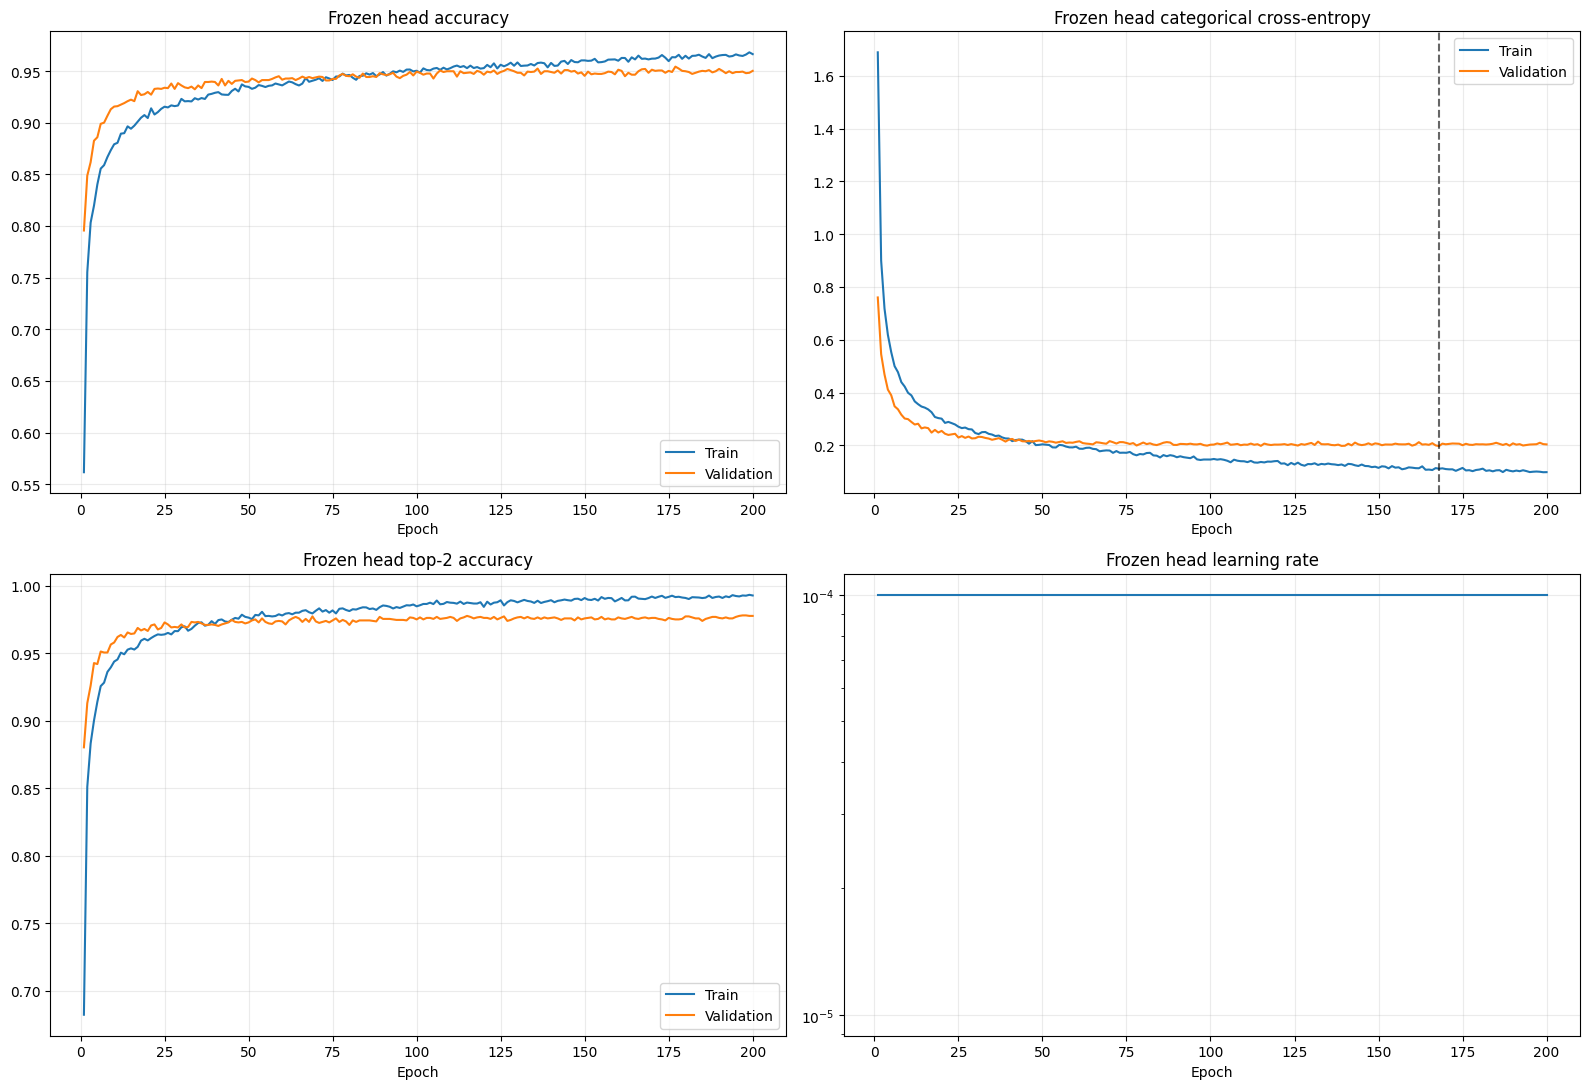

{
  "best_epoch": 168,
  "best_val_loss": 0.19757752120494843,
  "best_val_accuracy": 0.9520624279975891,
  "best_val_top2_accuracy": 0.9765886068344116,
  "epochs_completed": 200,
  "stopped_by_global_time_limit": false,
  "checkpoint_path": "/kaggle/working/convnextbase_zoolake_final_public_aug_correct_split_seed12345/best_frozen_model.keras"
}


In [5]:
tf.keras.backend.clear_session()

backbone = tf.keras.applications.ConvNeXtBase(
    include_top=False,
    include_preprocessing=True,
    weights="imagenet",
    input_shape=(*IMAGE_SIZE, 3),
    pooling=None,
    name="convnext_base",
)
backbone.trainable = False

inputs = tf.keras.Input(shape=(*IMAGE_SIZE, 3), name="image")
x = backbone(inputs)
x = tf.keras.layers.GlobalAveragePooling2D(
    name="global_average_pooling",
)(x)
x = tf.keras.layers.LayerNormalization(
    epsilon=1e-6,
    name="head_layer_norm",
)(x)
x = tf.keras.layers.Dropout(
    0.4,
    seed=SEED,
    name="head_dropout_1",
)(x)
x = tf.keras.layers.Dense(
    512,
    activation=tf.keras.activations.gelu,
    kernel_initializer=tf.keras.initializers.GlorotUniform(
        seed=SEED,
    ),
    bias_initializer="zeros",
    name="head_dense_512",
)(x)
x = tf.keras.layers.Dropout(
    0.3,
    seed=SEED + 1,
    name="head_dropout_2",
)(x)
outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    kernel_initializer=tf.keras.initializers.GlorotUniform(
        seed=SEED + 2,
    ),
    bias_initializer="zeros",
    name="predictions",
)(x)

model = tf.keras.Model(
    inputs,
    outputs,
    name="zoolake_convnextbase",
)

backbone_layers = recursive_layers(backbone)
batch_norm_layers = [
    layer
    for layer in backbone_layers
    if isinstance(layer, tf.keras.layers.BatchNormalization)
]
layer_norm_layers = [
    layer
    for layer in backbone_layers
    if isinstance(layer, tf.keras.layers.LayerNormalization)
]
input_normalization_layers = [
    layer
    for layer in backbone_layers
    if isinstance(layer, tf.keras.layers.Normalization)
]

assert len(batch_norm_layers) == 0
assert len(layer_norm_layers) > 0
assert len(input_normalization_layers) > 0
assert not backbone.trainable
assert model.count_params() == 88_111_267

frozen_normalization_audit = {
    "stage": "frozen",
    "backbone": backbone.name,
    "batch_normalization_layers": len(batch_norm_layers),
    "layer_normalization_layers": len(layer_norm_layers),
    "input_normalization_layers": len(input_normalization_layers),
    "backbone_trainable": bool(backbone.trainable),
    "model_parameters": int(model.count_params()),
    "trainable_parameters": parameter_count(model.trainable_weights),
    "non_trainable_parameters": parameter_count(
        model.non_trainable_weights
    ),
}
write_json(
    OUTPUT_DIR / "frozen_normalization_audit.json",
    frozen_normalization_audit,
)

summary_stream = io.StringIO()
model.summary(
    print_fn=lambda line: summary_stream.write(line + "\n"),
    expand_nested=True,
)
(OUTPUT_DIR / "model_summary.txt").write_text(
    summary_stream.getvalue(),
    encoding="utf-8",
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=FROZEN_LEARNING_RATE,
        beta_1=0.9,
        beta_2=0.999,
    ),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.TopKCategoricalAccuracy(
            k=2,
            name="top2_accuracy",
        ),
    ],
)

FROZEN_HISTORY_PATH = OUTPUT_DIR / "frozen_history.csv"
FROZEN_TIMING_PATH = OUTPUT_DIR / "frozen_epoch_times.csv"
pipeline_started_at = time.perf_counter()
frozen_timer = StageEpochLogger(
    stage="frozen",
    output_path=FROZEN_TIMING_PATH,
    pipeline_started_at=pipeline_started_at,
    wall_time_limit_hours=TOTAL_PIPELINE_WALL_TIME_LIMIT_HOURS,
)

frozen_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(BEST_FROZEN_MODEL_PATH),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=FROZEN_EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=1,
    ),
    frozen_timer,
    tf.keras.callbacks.CSVLogger(
        str(FROZEN_HISTORY_PATH),
        append=False,
    ),
    tf.keras.callbacks.TerminateOnNaN(),
]

train_generator.reset()
val_generator.reset()
frozen_history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=FROZEN_MAX_EPOCHS,
    callbacks=frozen_callbacks,
    verbose=2,
)

frozen_history_df = history_with_timing(
    frozen_history,
    FROZEN_TIMING_PATH,
    FROZEN_HISTORY_PATH,
)
save_training_curves(
    frozen_history_df,
    "Frozen head",
    OUTPUT_DIR / "frozen_training_curves.png",
)

frozen_best_row = frozen_history_df.loc[
    frozen_history_df["val_loss"].idxmin()
]
frozen_checkpoint_metadata = {
    "best_epoch": int(frozen_best_row["epoch"]),
    "best_val_loss": float(frozen_best_row["val_loss"]),
    "best_val_accuracy": float(
        frozen_best_row["val_accuracy"]
    ),
    "best_val_top2_accuracy": float(
        frozen_best_row["val_top2_accuracy"]
    ),
    "epochs_completed": int(len(frozen_history_df)),
    "stopped_by_global_time_limit": bool(
        frozen_timer.stopped_by_time_limit
    ),
    "checkpoint_path": str(BEST_FROZEN_MODEL_PATH),
}
write_json(
    OUTPUT_DIR / "frozen_best_checkpoint_metadata.json",
    frozen_checkpoint_metadata,
)
print(json.dumps(frozen_checkpoint_metadata, indent=2))


## 5. Validation-only frozen checkpoint report and full unfreeze

The frozen checkpoint is measured on validation only. The final test remains
unopened. Then the exact best frozen checkpoint is loaded, recursively
unfrozen, and recompiled with a fresh Adam optimizer.


In [6]:
frozen_model = tf.keras.models.load_model(
    BEST_FROZEN_MODEL_PATH,
    compile=False,
)
val_generator.reset()
frozen_val_probs = frozen_model.predict(
    val_generator,
    verbose=1,
)
y_val = np.asarray(val_generator.classes, dtype=np.int64)
assert frozen_val_probs.shape == (len(y_val), NUM_CLASSES)
assert np.allclose(
    frozen_val_probs.sum(axis=1),
    1.0,
    atol=1e-3,
)

frozen_validation_metrics, frozen_val_pred = calculate_metrics(
    y_val,
    frozen_val_probs,
    "validation",
    "frozen",
)
write_json(
    OUTPUT_DIR / "frozen_validation_metrics.json",
    frozen_validation_metrics,
)
save_per_class_results(
    y_val,
    frozen_val_pred,
    "validation",
    "frozen",
)
print("FROZEN VALIDATION METRICS")
print(json.dumps(frozen_validation_metrics, indent=2))

model = tf.keras.models.load_model(
    BEST_FROZEN_MODEL_PATH,
    compile=False,
)
convnext_backbones = [
    layer
    for layer in model.layers
    if isinstance(layer, tf.keras.Model)
    and "convnext" in layer.name.lower()
]
assert len(convnext_backbones) == 1, [
    layer.name
    for layer in convnext_backbones
]
backbone = convnext_backbones[0]

frozen_nested_layers_before = [
    layer.name
    for layer in [backbone] + recursive_layers(backbone)
    if not layer.trainable
]
assert frozen_nested_layers_before

set_trainable_recursive(backbone, True)
frozen_nested_layers_after = [
    layer.name
    for layer in [backbone] + recursive_layers(backbone)
    if not layer.trainable
]
assert not frozen_nested_layers_after, frozen_nested_layers_after

finetune_normalization_audit = {
    "stage": "full_finetune",
    "backbone": backbone.name,
    "frozen_nested_layers_before_unfreeze": int(
        len(frozen_nested_layers_before)
    ),
    "frozen_nested_layers_after_unfreeze": int(
        len(frozen_nested_layers_after)
    ),
    "model_parameters": int(model.count_params()),
    "trainable_parameters": parameter_count(model.trainable_weights),
    "non_trainable_parameters": parameter_count(
        model.non_trainable_weights
    ),
    "note": (
        "Normalization layer statistics can remain non-trainable weights "
        "even when every layer has trainable=True."
    ),
}
write_json(
    OUTPUT_DIR / "finetune_normalization_audit.json",
    finetune_normalization_audit,
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=FINETUNE_LEARNING_RATE,
        beta_1=0.9,
        beta_2=0.999,
    ),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.TopKCategoricalAccuracy(
            k=2,
            name="top2_accuracy",
        ),
    ],
)
print(json.dumps(finetune_normalization_audit, indent=2))


85/85 ━━━━━━━━━━━━━━━━━━━━ 19s 143ms/step
FROZEN VALIDATION METRICS
{
  "run_name": "convnextbase_zoolake_final_public_aug_correct_split_seed12345",
  "stage": "frozen",
  "split": "validation",
  "samples": 2691,
  "loss": 0.19757753610610962,
  "accuracy": 0.9520624303232998,
  "macro_precision": 0.8738543671934329,
  "macro_recall": 0.856747919191308,
  "macro_f1": 0.8551015085267218,
  "macro_f1_no_junk": 0.9028048607050068,
  "macro_f1_ge200": 0.9384316292908118,
  "macro_f1_ge200_no_junk": 0.9587099900627717,
  "top2_accuracy": 0.9765886287625418,
  "seed": 12345,
  "manifest_sha256": "84ca050319a314f1fbf532f553c1a557763b73a09b2e0f0692d2d6c8182706ad"
}
{
  "stage": "full_finetune",
  "backbone": "convnext_base",
  "frozen_nested_layers_before_unfreeze": 263,
  "frozen_nested_layers_after_unfreeze": 0,
  "model_parameters": 88111267,
  "trainable_parameters": 88111267,
  "non_trainable_parameters": 0,
  "note": "Normalization layer statistics can remain non-trainable weights even 

## 6. Optimized full fine-tuning

The public authors' code uses 1e-6 for fine-tuning, whereas the paper text
states a fixed 1e-7. We retain the 1e-6 plus ReduceLROnPlateau protocol that
defined the previous best ConvNeXt run.


Found 12558 validated image filenames belonging to 35 classes.
Found 2691 validated image filenames belonging to 35 classes.
Epoch 1/400


2026-08-10 17:58:08.004680: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-10 17:58:08.190112: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-10 17:58:08.455117: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-10 17:58:08.663216: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-10 18:00:43.342846: E external/local_xla/xla/stream_


Epoch 1: val_loss improved from None to 0.20156, saving model to /kaggle/working/convnextbase_zoolake_final_public_aug_correct_split_seed12345/best_finetuned_model.keras

Epoch 1: finished saving model to /kaggle/working/convnextbase_zoolake_final_public_aug_correct_split_seed12345/best_finetuned_model.keras
393/393 - 307s - 780ms/step - accuracy: 0.9685 - loss: 0.0951 - top2_accuracy: 0.9929 - val_accuracy: 0.9532 - val_loss: 0.2016 - val_top2_accuracy: 0.9788 - learning_rate: 1.0000e-06
Epoch 2/400

Epoch 2: val_loss improved from 0.20156 to 0.19974, saving model to /kaggle/working/convnextbase_zoolake_final_public_aug_correct_split_seed12345/best_finetuned_model.keras

Epoch 2: finished saving model to /kaggle/working/convnextbase_zoolake_final_public_aug_correct_split_seed12345/best_finetuned_model.keras
393/393 - 193s - 492ms/step - accuracy: 0.9680 - loss: 0.0871 - top2_accuracy: 0.9944 - val_accuracy: 0.9547 - val_loss: 0.1997 - val_top2_accuracy: 0.9792 - learning_rate: 1.0000

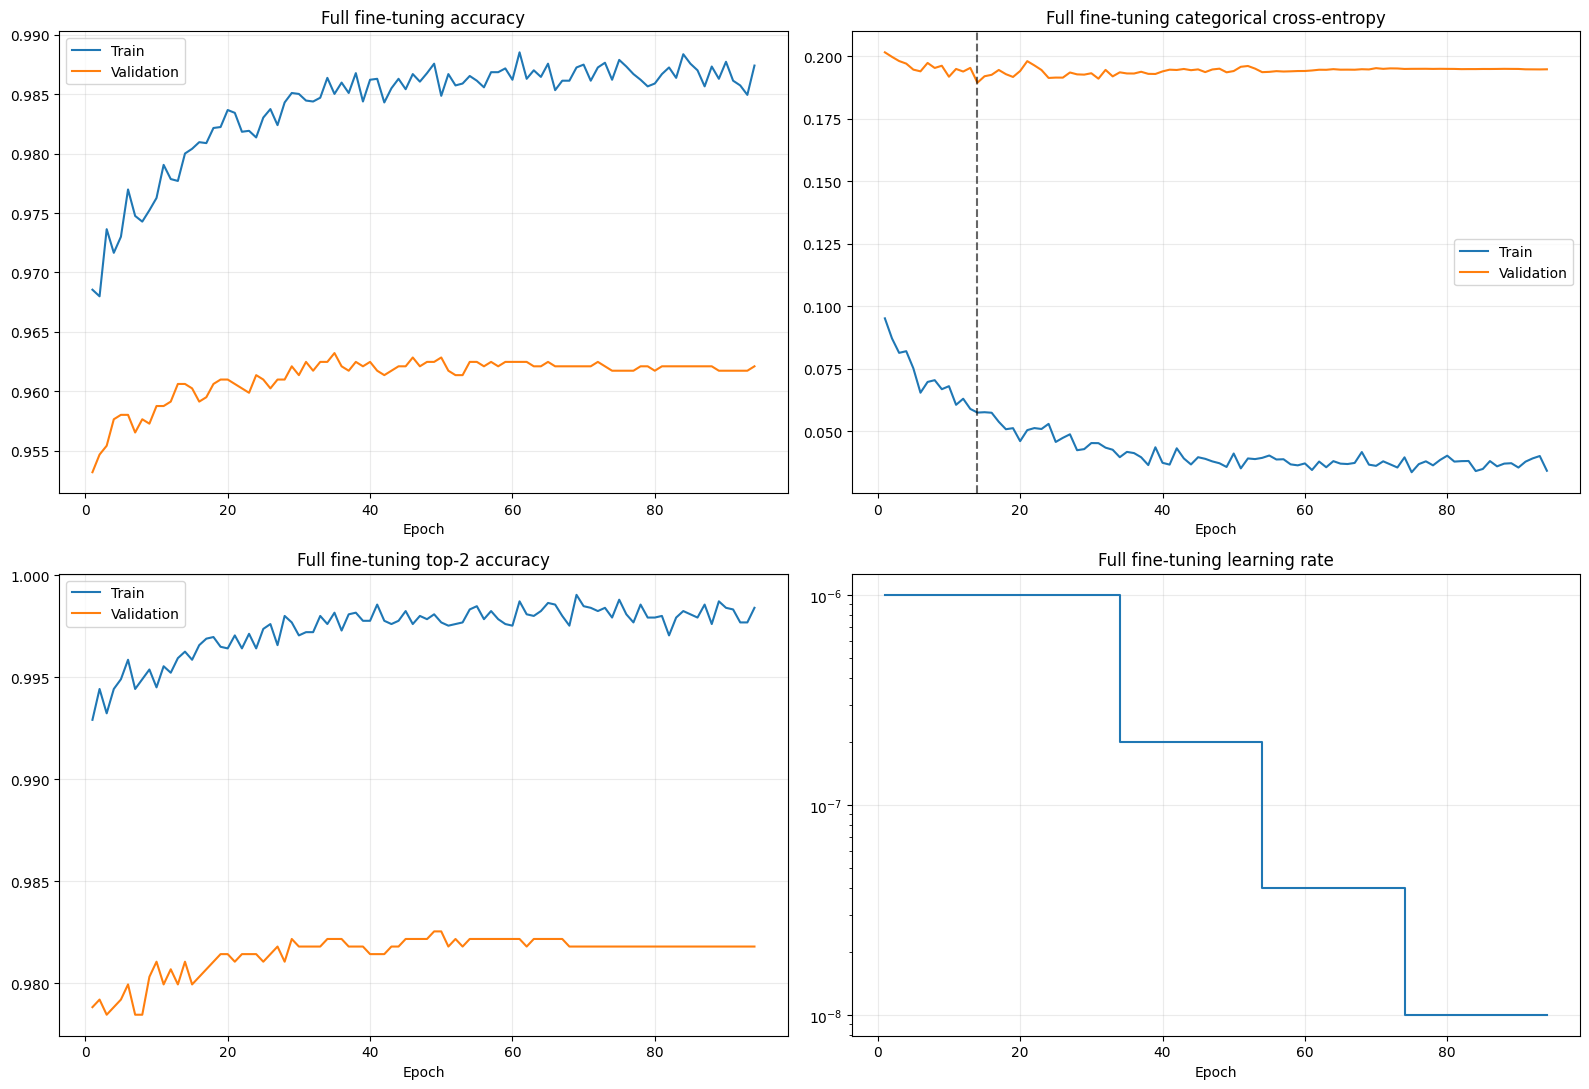

{
  "best_epoch": 14,
  "best_val_loss": 0.18941015005111694,
  "best_val_accuracy": 0.9606094360351562,
  "best_val_top2_accuracy": 0.9810479283332825,
  "learning_rate_at_best_epoch": 9.999999974752427e-07,
  "epochs_completed": 94,
  "stopped_by_global_time_limit": false,
  "total_pipeline_hours_at_end": 9.288152441850833,
  "checkpoint_path": "/kaggle/working/convnextbase_zoolake_final_public_aug_correct_split_seed12345/best_finetuned_model.keras"
}


In [7]:
FINETUNE_HISTORY_PATH = OUTPUT_DIR / "finetuned_history.csv"
FINETUNE_TIMING_PATH = OUTPUT_DIR / "finetuned_epoch_times.csv"

# A fresh iterator restarts the deterministic seed sequence for this stage,
# matching the earlier two-notebook frozen -> fine-tuning procedure.
finetune_train_generator = make_train_generator()
finetune_val_generator = make_validation_generator()

finetune_timer = StageEpochLogger(
    stage="full_finetune",
    output_path=FINETUNE_TIMING_PATH,
    pipeline_started_at=pipeline_started_at,
    wall_time_limit_hours=TOTAL_PIPELINE_WALL_TIME_LIMIT_HOURS,
)

finetune_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(BEST_FINETUNED_MODEL_PATH),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=REDUCE_LR_FACTOR,
        patience=REDUCE_LR_PATIENCE,
        min_delta=REDUCE_LR_MIN_DELTA,
        min_lr=MIN_LEARNING_RATE,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=FINETUNE_EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=1,
    ),
    finetune_timer,
    tf.keras.callbacks.CSVLogger(
        str(FINETUNE_HISTORY_PATH),
        append=False,
    ),
    tf.keras.callbacks.TerminateOnNaN(),
]

finetune_train_generator.reset()
finetune_val_generator.reset()
finetune_history = model.fit(
    finetune_train_generator,
    validation_data=finetune_val_generator,
    epochs=FINETUNE_MAX_EPOCHS,
    callbacks=finetune_callbacks,
    verbose=2,
)

finetune_history_df = history_with_timing(
    finetune_history,
    FINETUNE_TIMING_PATH,
    FINETUNE_HISTORY_PATH,
)
save_training_curves(
    finetune_history_df,
    "Full fine-tuning",
    OUTPUT_DIR / "finetuned_training_curves.png",
)

finetune_best_row = finetune_history_df.loc[
    finetune_history_df["val_loss"].idxmin()
]
finetune_checkpoint_metadata = {
    "best_epoch": int(finetune_best_row["epoch"]),
    "best_val_loss": float(finetune_best_row["val_loss"]),
    "best_val_accuracy": float(
        finetune_best_row["val_accuracy"]
    ),
    "best_val_top2_accuracy": float(
        finetune_best_row["val_top2_accuracy"]
    ),
    "learning_rate_at_best_epoch": float(
        finetune_best_row["learning_rate"]
    ),
    "epochs_completed": int(len(finetune_history_df)),
    "stopped_by_global_time_limit": bool(
        finetune_timer.stopped_by_time_limit
    ),
    "total_pipeline_hours_at_end": float(
        finetune_history_df["pipeline_seconds"].iloc[-1] / 3600
    ),
    "checkpoint_path": str(BEST_FINETUNED_MODEL_PATH),
}
write_json(
    OUTPUT_DIR / "finetuned_best_checkpoint_metadata.json",
    finetune_checkpoint_metadata,
)
print(json.dumps(finetune_checkpoint_metadata, indent=2))


## 7. Final validation report and one-time final-test evaluation

At this point the architecture, augmentation, training protocol, and checkpoint
are fixed. Only now is a final-test generator created and its pixels read.
No TTA, threshold tuning, calibration, or post-test model selection is applied.


Found 2691 validated image filenames belonging to 35 classes.
85/85 ━━━━━━━━━━━━━━━━━━━━ 20s 158ms/step
Found 2691 validated image filenames belonging to 35 classes.
85/85 ━━━━━━━━━━━━━━━━━━━━ 21s 243ms/step


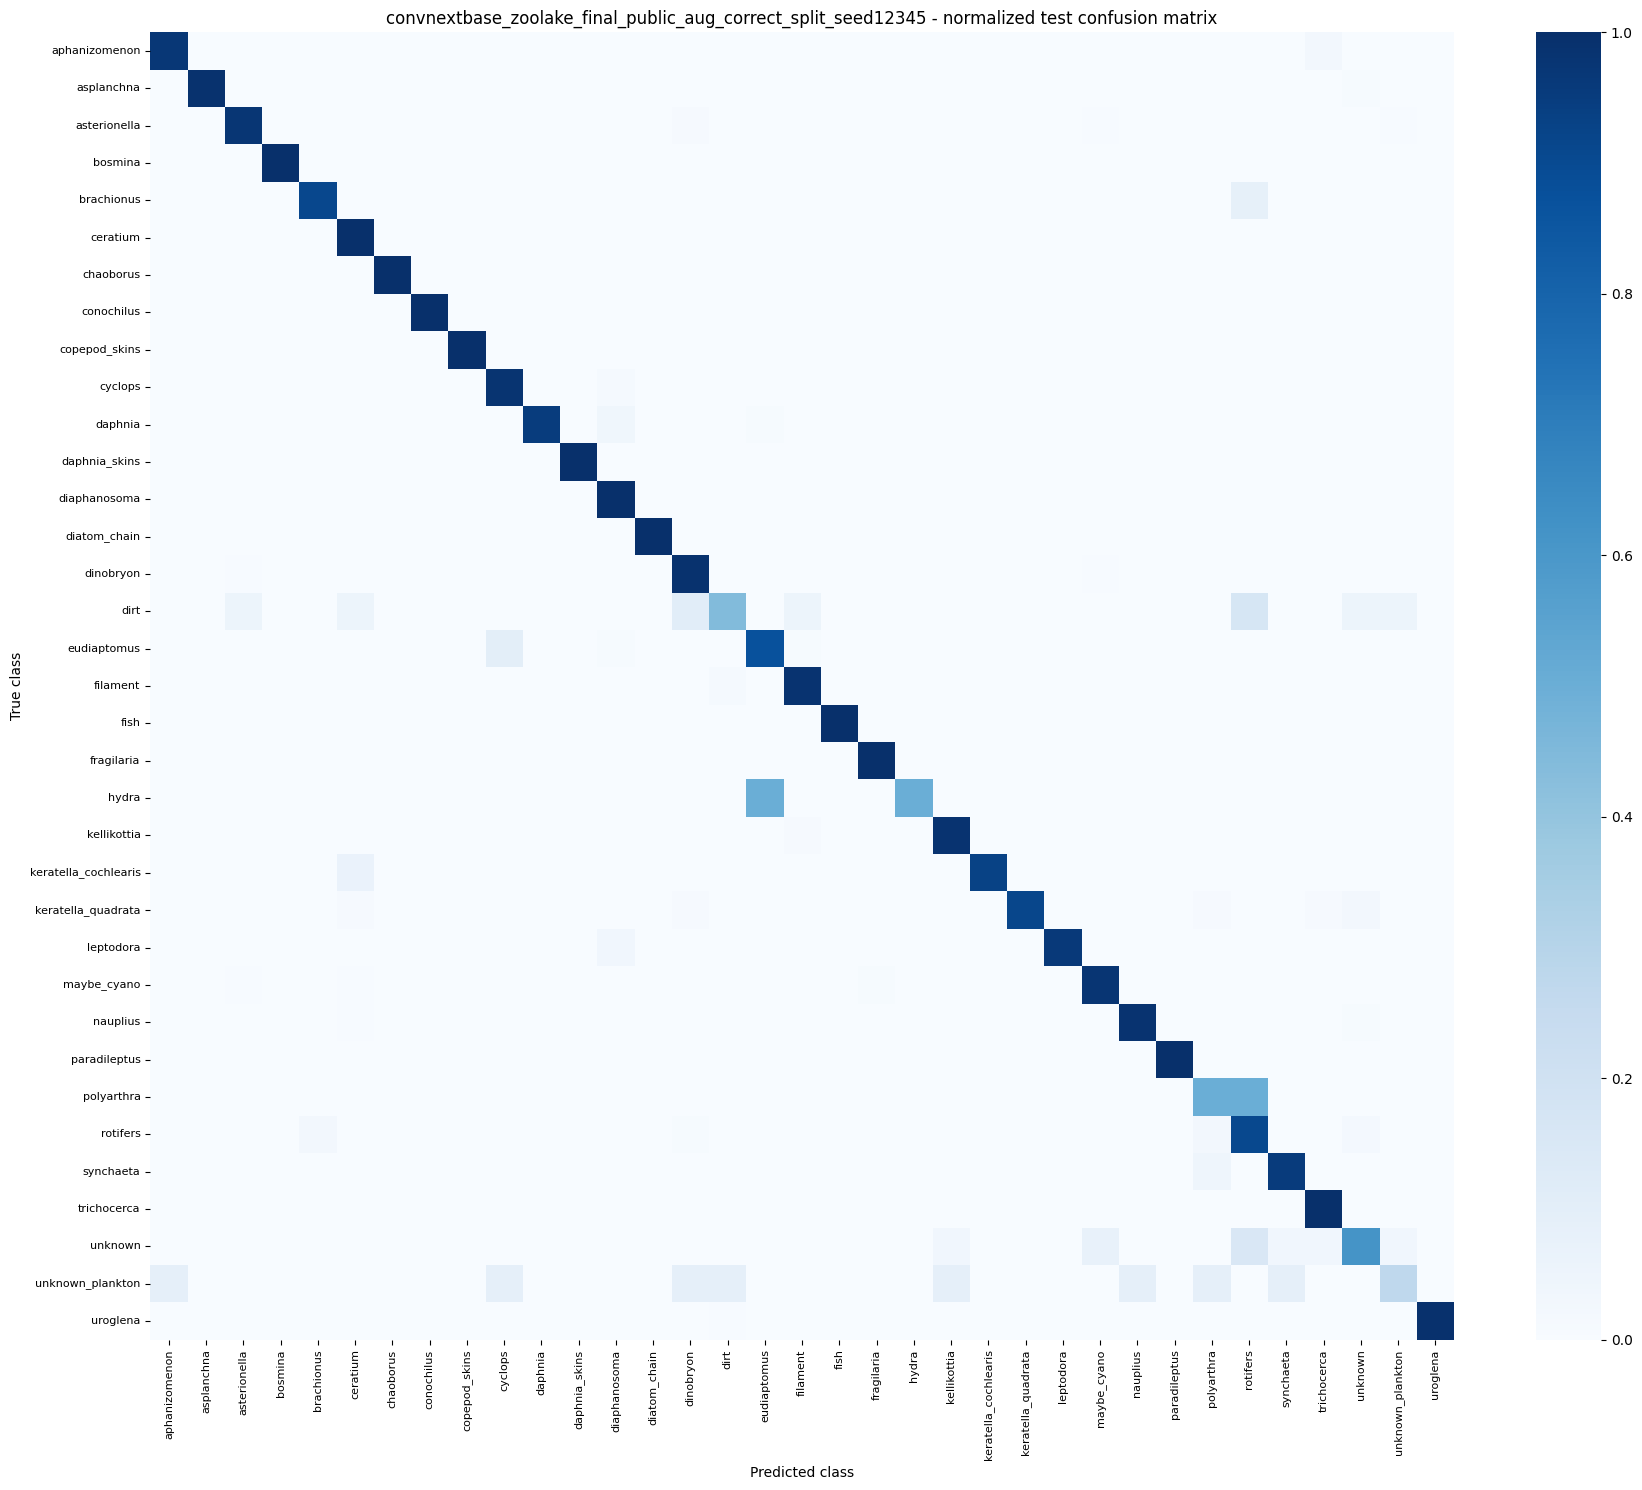

Saved reports archive: /kaggle/working/convnextbase_zoolake_final_public_aug_correct_split_seed12345_reports.zip
FINAL VALIDATION METRICS
{
  "run_name": "convnextbase_zoolake_final_public_aug_correct_split_seed12345",
  "stage": "full_finetune",
  "split": "validation",
  "samples": 2691,
  "loss": 0.18941015005111694,
  "accuracy": 0.9606094388703085,
  "macro_precision": 0.8883689688302409,
  "macro_recall": 0.8692945449887441,
  "macro_f1": 0.8682106578665963,
  "macro_f1_no_junk": 0.9112068151443565,
  "macro_f1_ge200": 0.9518013548334205,
  "macro_f1_ge200_no_junk": 0.9700321147039778,
  "top2_accuracy": 0.9810479375696767,
  "seed": 12345,
  "manifest_sha256": "84ca050319a314f1fbf532f553c1a557763b73a09b2e0f0692d2d6c8182706ad"
}
FINAL TEST METRICS
{
  "run_name": "convnextbase_zoolake_final_public_aug_correct_split_seed12345",
  "stage": "full_finetune",
  "split": "test",
  "samples": 2691,
  "loss": 0.13343116641044617,
  "accuracy": 0.9654403567447045,
  "macro_precision": 0.9

In [8]:
best_model = tf.keras.models.load_model(
    BEST_FINETUNED_MODEL_PATH,
    compile=False,
)

final_val_generator = make_validation_generator()
final_val_generator.reset()
val_probs = best_model.predict(
    final_val_generator,
    verbose=1,
)
y_val = np.asarray(
    final_val_generator.classes,
    dtype=np.int64,
)
assert val_probs.shape == (len(y_val), NUM_CLASSES)
assert np.all(np.isfinite(val_probs))
assert np.allclose(val_probs.sum(axis=1), 1.0, atol=1e-3)

validation_metrics, y_val_pred = calculate_metrics(
    y_val,
    val_probs,
    "validation",
    "full_finetune",
)
write_json(
    OUTPUT_DIR / "finetuned_validation_metrics.json",
    validation_metrics,
)
save_per_class_results(
    y_val,
    y_val_pred,
    "validation",
    "full_finetune",
)

# First and only construction/iteration of the final-test generator.
test_generator = evaluation_datagen.flow_from_dataframe(
    test_df,
    shuffle=False,
    **common_generator_settings,
)
assert test_generator.class_indices == expected_mapping
assert np.array_equal(
    test_generator.classes,
    test_df["class_index"].to_numpy(),
)

test_generator.reset()
test_probs = best_model.predict(
    test_generator,
    verbose=1,
)
y_test = np.asarray(test_generator.classes, dtype=np.int64)
assert test_probs.shape == (len(y_test), NUM_CLASSES)
assert np.all(np.isfinite(test_probs))
assert np.allclose(test_probs.sum(axis=1), 1.0, atol=1e-3)

test_metrics, y_test_pred = calculate_metrics(
    y_test,
    test_probs,
    "test",
    "full_finetune",
)
write_json(
    OUTPUT_DIR / "finetuned_test_metrics.json",
    test_metrics,
)
save_per_class_results(
    y_test,
    y_test_pred,
    "test",
    "full_finetune",
)
save_confusion_matrix(
    y_test,
    y_test_pred,
    "test",
    "full_finetune",
)

bootstrap_result = stratified_bootstrap_macro_f1(
    y_test,
    y_test_pred,
    n_resamples=BOOTSTRAP_RESAMPLES,
    seed=SEED,
)
write_json(
    OUTPUT_DIR / "test_macro_f1_bootstrap_ci.json",
    bootstrap_result,
)

test_access_log = {
    "test_generator_created_after_checkpoint_selection": True,
    "test_pixel_prediction_passes": 1,
    "test_time_augmentation": False,
    "test_results_used_for_model_selection": False,
    "evaluated_checkpoint": str(BEST_FINETUNED_MODEL_PATH),
}
write_json(
    OUTPUT_DIR / "test_access_log.json",
    test_access_log,
)

np.savez_compressed(
    OUTPUT_DIR / "predictions.npz",
    frozen_val_probs=np.asarray(
        frozen_val_probs,
        dtype=np.float32,
    ),
    val_probs=np.asarray(val_probs, dtype=np.float32),
    test_probs=np.asarray(test_probs, dtype=np.float32),
    y_val=y_val,
    y_test=y_test,
    class_names=np.asarray(CLASS_NAMES, dtype=str),
    train_counts=train_counts,
    validation_counts=val_counts,
    test_counts=test_counts,
    total_counts=total_counts,
    val_filepaths=np.asarray(
        final_val_generator.filepaths,
        dtype=str,
    ),
    test_filepaths=np.asarray(
        test_generator.filepaths,
        dtype=str,
    ),
    run_name=np.asarray(RUN_NAME),
    stage=np.asarray("full_finetune"),
    seed=np.asarray(SEED, dtype=np.int64),
    manifest_sha256=np.asarray(MANIFEST_SHA256),
    augmentation_variant=np.asarray(
        "authors_public_code_rotation90_zoom0.2_shear10"
    ),
)

final_summary = {
    "run_name": RUN_NAME,
    "frozen_best_checkpoint": frozen_checkpoint_metadata,
    "frozen_validation_metrics": frozen_validation_metrics,
    "finetuned_best_checkpoint": finetune_checkpoint_metadata,
    "finetuned_validation_metrics": validation_metrics,
    "finetuned_test_metrics": test_metrics,
    "test_macro_f1_bootstrap": bootstrap_result,
    "test_access_log": test_access_log,
}
write_json(OUTPUT_DIR / "final_summary.json", final_summary)

archive_path = (
    Path("/kaggle/working")
    / f"{RUN_NAME}_reports.zip"
)
create_reports_archive(OUTPUT_DIR, archive_path)

print("FINAL VALIDATION METRICS")
print(json.dumps(validation_metrics, indent=2))
print("FINAL TEST METRICS")
print(json.dumps(test_metrics, indent=2))
print("TEST MACRO-F1 BOOTSTRAP")
print(json.dumps(bootstrap_result, indent=2))
print("Best frozen model:", BEST_FROZEN_MODEL_PATH)
print("Best fine-tuned model:", BEST_FINETUNED_MODEL_PATH)
print("Reports ZIP:", archive_path)


## Interpretation rule

This run closes the experimental phase. Report the validation-selected
fine-tuned checkpoint, its one-time final-test metrics, and the bootstrap
interval. Do not introduce a further augmentation, sampling, calibration, or
checkpoint choice after seeing the final-test result.
